# DADA2 paired-end pipeline via **`pydada2`**

Full Illumina MiSeq DADA2 workflow on the two paired fixtures
(`sam1F.fastq.gz`+`sam1R.fastq.gz`, `sam2F.fastq.gz`+`sam2R.fastq.gz`)
that ship with the upstream R DADA2 package.

Pipeline (all in pure Python, no R):

1. **`derep_fastq`** — collapse identical reads + average per-position quality.
2. **`dada`** — divisive amplicon denoising on each sample × strand.
3. **`merge_pairs`** — join denoised forward + reverse reads.
4. **`make_sequence_table`** — assemble sample × ASV table.
5. **`remove_bimera_denovo`** — flag and drop two-parent chimeras.
6. (Optional) **`assign_taxonomy`** — RDP naive Bayes against a reference.

Mirrors `https://benjjneb.github.io/dada2/tutorial.html` step for step.


In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pydada2
from pydada2 import (
    derep_fastq, dada, merge_pairs,
    make_sequence_table, remove_bimera_denovo,
)

EXTDATA = '/scratch/users/steorra/analysis/omicverse_dev/cache/dada2_src/inst/extdata'
samples = ['sam1', 'sam2']
print('pydada2 version:', pydada2.__version__)

pydada2 version: 0.1.0


## 1. Dereplicate forward + reverse reads

The fixtures are already quality-filtered. In a real workflow you
would call `filter_and_trim(...)` first.

In [2]:
derepsF = {s: derep_fastq(f'{EXTDATA}/{s}F.fastq.gz') for s in samples}
derepsR = {s: derep_fastq(f'{EXTDATA}/{s}R.fastq.gz') for s in samples}

summary = pd.DataFrame({
    s: {'reads_F': int(derepsF[s].abundances().sum()),
        'uniq_F':  derepsF[s].n_unique,
        'reads_R': int(derepsR[s].abundances().sum()),
        'uniq_R':  derepsR[s].n_unique}
    for s in samples
}).T
summary

,reads_F,uniq_F,reads_R,uniq_R
sam1,1500,896,1500,1373
sam2,1500,909,1500,1401


## 2. Run `dada()` on each sample × strand

Single shared error matrix across all four `dada()` calls (identical
to the R-parity test setup). For real data you'd estimate this from
the data via `learn_errors(...)`.

In [3]:
err = np.full((16, 41), 1e-3)
for i in range(4):
    err[i*4 + i] = 1 - 3*1e-3

dadaF = {s: dada(derepsF[s], err=err, verbose=False) for s in samples}
dadaR = {s: dada(derepsR[s], err=err, verbose=False) for s in samples}

asv_summary = pd.DataFrame({
    s: {'F_ASVs': len(dadaF[s]['clustering']),
        'R_ASVs': len(dadaR[s]['clustering'])}
    for s in samples
}).T
asv_summary

,F_ASVs,R_ASVs
sam1,9,4
sam2,10,4


## 3. Merge paired reads

`merge_pairs` aligns each (forward ASV, reverse ASV) candidate via
ends-free Needleman-Wunsch with heavy mismatch / gap penalties (the
same parameters R DADA2 uses internally). Reads pass when the
overlap ≥ `minOverlap` and contain ≤ `maxMismatch` differences.

In [4]:
mergers = {
    s: merge_pairs(dadaF[s], derepsF[s], dadaR[s], derepsR[s],
                    minOverlap=12, maxMismatch=0, verbose=False)
    for s in samples
}
for s in samples:
    n_seq = len(mergers[s])
    n_reads = int(mergers[s]['abundance'].sum())
    print(f'{s}: {n_reads} merged reads in {n_seq} unique merged sequences.')

mergers['sam1'].head()

sam1: 886 merged reads in 4 unique merged sequences.
sam2: 902 merged reads in 4 unique merged sequences.


,forward,reverse,abundance,sequence,nmatch,nmismatch,nindel,prefer,accept
0,0,0,460,TACGGAGGATCCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAG...,247,0,0,1,True
1,1,1,334,TACGGAGGATCCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAG...,247,0,0,1,True
2,2,2,53,TACGGAGGATCCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAG...,247,0,0,1,True
3,3,3,39,TACGTAGGGGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAG...,247,0,0,1,True


## 4. Build the sample × ASV table

seqtab shape: 2 samples × 4 ASVs


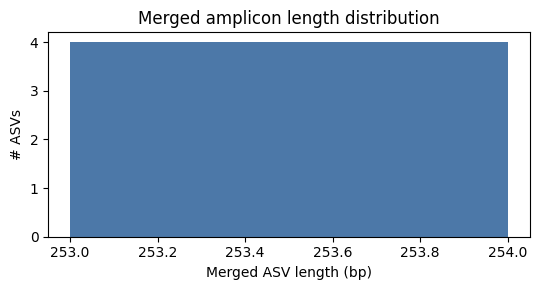

In [5]:
seqtab = make_sequence_table(mergers)
print(f'seqtab shape: {seqtab.shape[0]} samples × {seqtab.shape[1]} ASVs')

# Distribution of merged-ASV lengths
lengths = [len(s) for s in seqtab.columns]
fig, ax = plt.subplots(figsize=(5.5, 3))
ax.hist(lengths, bins=range(min(lengths), max(lengths)+2), color='#4c78a8')
ax.set_xlabel('Merged ASV length (bp)'); ax.set_ylabel('# ASVs')
ax.set_title('Merged amplicon length distribution')
plt.tight_layout(); plt.show()

## 5. Remove de-novo bimeras (chimeras)

`remove_bimera_denovo(method='consensus')` flags an ASV as bimeric
if a per-sample vote across its observations exceeds
`min_sample_fraction` (default 0.9). Two-parent chimeras are
identified via the kernel in `chimeras.is_bimera`, which exactly
ports the C++ `C_is_bimera` from R DADA2.

In [6]:
seqtab_nochim = remove_bimera_denovo(seqtab, method='consensus', verbose=True)
print(f'after chimera removal: {seqtab.shape[1]} → {seqtab_nochim.shape[1]} ASVs')
print(f'reads kept: {int(seqtab_nochim.values.sum())} / {int(seqtab.values.sum())}'
       f' ({100*seqtab_nochim.values.sum()/max(1, seqtab.values.sum()):.1f}%)')
seqtab_nochim

Identified 0 bimeras out of 4 input sequences.
after chimera removal: 4 → 4 ASVs
reads kept: 1788 / 1788 (100.0%)


,TACGGAGGATCCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGGTGGATTGTTAAGTCAGTTGTGAAAGTTTGCGGCTCAACCGTAAAATTGCAGTTGAAACTGGCAGTCTTGAGTACAGTAGAGGTGGGCGGAATTCGTGGTGTAGCGGTGAAATGCTTAGATATCACGAAGAACTCCGATTGCGAAGGCAGCTCACTAGACTGTTACTGACACTGATGCTCGAAAGTGTGGGTATCAAACAGG,TACGGAGGATCCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGATGGATGTTTAAGTCAGTTGTGAAAGTTTGCGGCTCAACCGTAAAATTGCAGTTGATACTGGATATCTTGAGTGCAGTTGAGGCAGGCGGAATTCGTGGTGTAGCGGTGAAATGCTTAGATATCACGAAGAACTCCGATTGCGAAGGCAGCCTGCTAAGCTGCAACTGACATTGAGGCTCGAAAGTGTGGGTATCAAACAGG,TACGGAGGATCCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGGCGGACTATTAAGTCAGCTGTGAAAGTTTGCGGCTCAACCGTAAAATTGCAGTTGATACTGGTCGTCTTGAGTGCAGTAGAGGTAGGCGGAATTCGTGGTGTAGCGGTGAAATGCTTAGATATCACGAAGAACTCCGATTGCGAAGGCAGCTTACTGGACTGTAACTGACGCTGATGCTCGAAAGTGTGGGTATCAAACAGG,TACGTAGGGGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGTAGACGGTGATGTAAGTCAGATGTGAAAGCCCGGGGCTCAACCCCGGGACTGCATTTGAAACTATGTTGCTAGAGTGCAGGAGAGGTAAGTGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACACCAGTGGCGAAGGCGGCTTACTGGACTGTAACTGACGTTGAGGCTCGAAAGCGTGGGGAGCAAACAGG
sam1,460,334,53,39
sam2,466,346,47,43


## 6. (Optional) Taxonomy assignment

`assign_taxonomy` ports R DADA2's RDP-style naive-Bayesian
classifier with kmer 8 + 100 bootstraps. Provide it a reference
fasta whose headers are taxonomy strings
(`Kingdom;Phylum;Class;...`).

Skipped here — the bundled `example_train_set.fa.gz` is a tiny demo
and not representative of a real reference (SILVA / GTDB / UNITE).
The call signature is:

```python
from pydada2 import assign_taxonomy
taxa = assign_taxonomy(seqtab_nochim,
                       ref_fasta='silva_nr99.fa.gz',
                       minBoot=50, tryRC=False)
```


## Summary

End-to-end pure-Python DADA2 pipeline:

```python
from pydada2 import (derep_fastq, dada, merge_pairs,
                      make_sequence_table, remove_bimera_denovo,
                      assign_taxonomy)

drpF = derep_fastq('F.fastq.gz')
drpR = derep_fastq('R.fastq.gz')
ddF  = dada(drpF, err=err)
ddR  = dada(drpR, err=err)
mer  = merge_pairs(ddF, drpF, ddR, drpR)
seqtab        = make_sequence_table({{'sample': mer}})
seqtab_nochim = remove_bimera_denovo(seqtab, method='consensus')
taxa          = assign_taxonomy(seqtab_nochim, ref_fasta='silva_nr99.fa.gz')
```

This is the same call sequence as the R DADA2 MiSeq SOP tutorial,
in pure Python and AnnData/pandas-friendly throughout.
